# Attractor cell sets

`CMGDB.attractor_cells` returns the **forward-invariant cell set** of an
attractor: starting from the grid cells of the attractor's Morse set(s), it
closes that set under the map graph's forward adjacency. This is the
attractor *itself* (where trajectories settle), in contrast to its basin /
region of attraction (the reverse-reachable set computed by
`CMGDB.compute_exact_roa`).

We use the bistable 2-D Leslie map, which has two coexisting attractors, and
plot the cells of each.

In [1]:
import math
import tempfile

import numpy as np
import matplotlib.pyplot as plt

import CMGDB
from CMGDB.morse_graph_parser import MorseGraph
from CMGDB.cmgdb_roa import attractor_cells

## Compute the Morse graph of the bistable Leslie map

$f(x_0, x_1) = \big((\theta x_0 + \theta x_1)\,e^{-0.1(x_0+x_1)},\ 0.7\,x_0\big)$,
$\theta = 23.5$, on $[0, 110] \times [0, 77]$. The grid is refined enough to
separate the two attractors (takes roughly 45 s).

In [2]:
def leslie(x):
    theta = 23.5
    return [(theta * x[0] + theta * x[1]) * math.exp(-0.1 * (x[0] + x[1])), 0.7 * x[0]]

def leslie_box_map(rect):
    x0_lo, x1_lo, x0_hi, x1_hi = rect
    corners = [leslie([x0_lo, x1_lo]), leslie([x0_hi, x1_lo]),
               leslie([x0_lo, x1_hi]), leslie([x0_hi, x1_hi])]
    y0 = [c[0] for c in corners]; y1 = [c[1] for c in corners]
    return [min(y0), min(y1), max(y0), max(y1)]

LOWER_BOUNDS = [-0.001, -0.001]
UPPER_BOUNDS = [110.0, 77.0]
model = CMGDB.Model(23, 25, 23, 10000, LOWER_BOUNDS, UPPER_BOUNDS, leslie_box_map)

print("Running CMGDB (~45 s)...")
cmgdb_mg, map_graph = CMGDB.ComputeMorseGraph(model)
dot = CMGDB.PlotMorseGraph(cmgdb_mg).source
with tempfile.NamedTemporaryFile("w", suffix=".dot", delete=False) as f:
    f.write(dot); dot_path = f.name
mg = MorseGraph.from_dot(dot_path)

attractor_nodes = sorted(mg.minimal)
print(f"{cmgdb_mg.num_vertices()} Morse sets; attractor (minimal) nodes: {attractor_nodes}")

Running CMGDB (~45 s)...


5 Morse sets; attractor (minimal) nodes: [0, 1]


## Extract and plot each attractor's cells

For each attractor node we call `attractor_cells`, then look up each cell's
box geometry with `phase_space_box` and scatter the box centres.

attractor 0: 8072 forward-invariant cells
attractor 1: 64476 forward-invariant cells


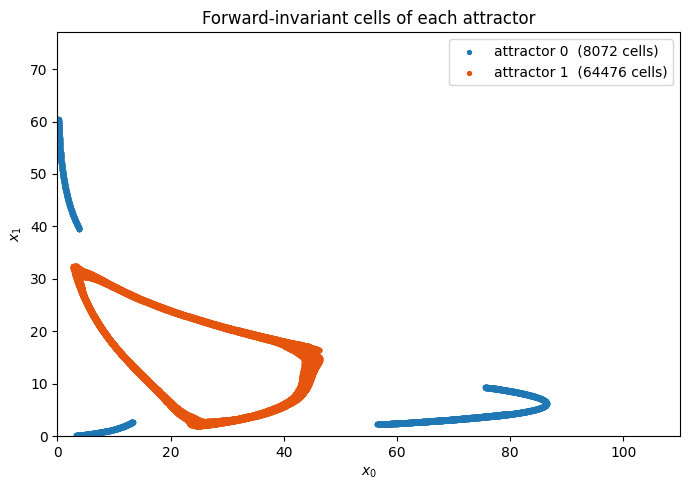

In [3]:
colors = ["#1f77b4", "#e6550d", "#31a354", "#9467bd"]

fig, ax = plt.subplots(figsize=(7, 5))
for i, a in enumerate(attractor_nodes):
    cells = attractor_cells(map_graph, cmgdb_mg, [a])
    boxes = np.array([cmgdb_mg.phase_space_box(c) for c in cells])
    cx = 0.5 * (boxes[:, 0] + boxes[:, 2])
    cy = 0.5 * (boxes[:, 1] + boxes[:, 3])
    ax.scatter(cx, cy, s=8, color=colors[i % len(colors)],
               label=f"attractor {a}  ({len(cells)} cells)")
    print(f"attractor {a}: {len(cells)} forward-invariant cells")

ax.set_xlabel("$x_0$"); ax.set_ylabel("$x_1$")
ax.set_xlim(LOWER_BOUNDS[0], UPPER_BOUNDS[0])
ax.set_ylim(LOWER_BOUNDS[1], UPPER_BOUNDS[1])
ax.legend(loc="upper right")
ax.set_title("Forward-invariant cells of each attractor")
plt.tight_layout(); plt.show()